# Stage 2: Quality Control on Gene Expression Data

This notebook performs QC on the trastuzumab breast cancer gene expression data:
- Check for missing/invalid values
- Identify all-zero samples and genes
- Filter low-expression genes
- Generate QC visualizations

In [1]:
! pip install -U pyrefinebio "pyrate-limiter==2.10.0"


In [2]:
import pickle
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

sns.set_style('whitegrid')

In [3]:
# Set repository root
os.environ['BIO_REPPO_ROOT'] = r"C:\Users\Jesse\Google Drive\Learning\freelance\biodata_portfolio"
repo_root = Path(os.environ['BIO_REPPO_ROOT'])

print(f"Repository root: {repo_root}")

Repository root: C:\Users\Jesse\Google Drive\Learning\freelance\biodata_portfolio


# optional: download data:
we can use the refine bio website to download the 4 experiments by searching fro the GSE IDS.
I'll demonstarte that here as well:
`series_list = ["GSE37946", "GSE42822", "GSE50948",'GSE66305']`
https://www.refine.bio/search?offset=0&limit=10&ordering=_score&num_downloadable_samples__gt=0&search=GSE66399

we can also use the package, pyrefinebio

(`pip install pyrefinebio`) but it's buggy so we have to use cli.
in terminal 

run from terminal, but might work in jupyter as well

In [29]:
# Load the TSV data with Polars (much faster than pandas)
data_path = Path('../data/RB_trastuzumab_series/HOMO_SAPIENS/HOMO_SAPIENS.tsv')
metadata_path = Path('../data/RB_trastuzumab_series/HOMO_SAPIENS/metadata_HOMO_SAPIENS.tsv')

# Load gene expression data
print("Loading gene expression data with Polars...")
genexp_pl = pl.read_csv(data_path, separator='\t')
print(f"Gene expression shape: {genexp_pl.shape}")

# Load metadata with increased schema inference length to handle mixed types
print("\nLoading metadata...")
metadata_pl = pl.read_csv(metadata_path, separator='\t', infer_schema_length=10000)
print(f"Metadata shape: {metadata_pl.shape}")

# Save to CSV for faster loading
print("\nSaving to CSV format...")
genexp_pl.write_csv('../data/rb_trastuzumab_genexp_polars.csv')
metadata_pl.write_csv('../data/rb_trastuzumab_metadata_polars.csv')

# Save to Parquet (most efficient format)
print("Saving to Parquet format...")
genexp_pl.write_parquet('../data/rb_trastuzumab_genexp.parquet')
metadata_pl.write_parquet('../data/rb_trastuzumab_metadata.parquet')

print("\n✓ Data saved in CSV and Parquet formats")
print(f"  - CSV: ../data/rb_trastuzumab_genexp_polars.csv")
print(f"  - Parquet: ../data/rb_trastuzumab_genexp.parquet")

Loading gene expression data with Polars...
Gene expression shape: (11868, 375)

Loading metadata...
Metadata shape: (374, 113)

Saving to CSV format...
Saving to Parquet format...

✓ Data saved in CSV and Parquet formats
  - CSV: ../data/rb_trastuzumab_genexp_polars.csv
  - Parquet: ../data/rb_trastuzumab_genexp.parquet


## 1. Load Gene Expression Data from Parquet

Now using the faster Parquet format instead of pickle

In [30]:
# Load gene expression data from Parquet (much faster than pickle)
genexp_pl = pl.read_parquet('../data/rb_trastuzumab_genexp.parquet')
metadata_pl = pl.read_parquet('../data/rb_trastuzumab_metadata.parquet')

print(f"Gene expression shape: {genexp_pl.shape}")
print(f"Metadata shape: {metadata_pl.shape}")

# Convert to numpy array for compatibility with rest of notebook
# First column is typically gene names/IDs, so we exclude it
gene_col = genexp_pl.columns[0]
sample_cols = genexp_pl.columns[1:]

genexp = genexp_pl.select(sample_cols).to_numpy().T.astype(np.float32)

print(f"\nNumpy array shape: {genexp.shape}")
print(f"Data type: {genexp.dtype}")
print(f"Samples: {genexp.shape[0]}, Genes: {genexp.shape[1]}")

Gene expression shape: (11868, 375)
Metadata shape: (374, 113)

Numpy array shape: (374, 11868)
Data type: float32
Samples: 374, Genes: 11868


## load RB genaexp data

## 2. Exploratory Data Analysis

In [34]:
# Convert to DataFrame for EDA
genexp_df = pd.DataFrame(genexp)

# Basic statistics
print("\nBasic Statistics:")
print(genexp_df.T.describe())

print(f"\nMin value: {genexp_df.T.min().min()}")
print(f"Max value: {genexp_df.T.max().max()}")
print(f"Mean expression: {genexp_df.T.mean().mean():.2f}")
print(f"Median expression: {genexp_df.T.median().median():.2f}")


Basic Statistics:
                0             1             2             3             4    \
count  11868.000000  11868.000000  11868.000000  11868.000000  11868.000000   
mean       2.505808      2.505808      2.505808      2.505807      2.505807   
std        7.400069      7.400069      7.400069      7.400069      7.400069   
min       -0.815156     -0.815156     -0.815156     -0.815156     -0.815156   
25%        0.146292      0.146292      0.146292      0.146292      0.146292   
50%        0.709434      0.709434      0.709434      0.709434      0.709434   
75%        2.309195      2.309195      2.309195      2.309195      2.309195   
max      197.476135    197.476135    197.476135    197.476135    197.476135   

                5             6             7             8             9    \
count  11868.000000  11868.000000  11868.000000  11868.000000  11868.000000   
mean       2.505808      2.505808      2.505808      2.505808      2.505808   
std        7.400069      7.40006

assuming that we are talking about log 2 values, a max of 197 is absurd.
we also need to understand the source of negative values.   
lets start with the massive value


so it's clearly part of the quantile norm applied to each sample. the biological meaning of the value is unclear. we will simply recall that quantile norm essentially returns a ranking, but the ranks aren't evenly spaced. 
i suggest that when we come to modelling, we compare results with and without standard scaling.

looking at the values below, we see that of the 20k quantiles, **~19500 are below 15**, which actually fits log2 values. so this suggests that the values larger than that, are the reuslt of an imputation. we should consider ignoring those overly large values in analysis.

### examine refrence for qnrom

In [8]:

import requests
# Define the API endpoint for Homo sapiens targets.
api_url = "https://api.refine.bio/v1/qn_targets/homo_sapiens"

# Query the API endpoint.
response = requests.get(api_url)
response.raise_for_status()  # Raise an error if the request failed

# Parse the JSON response.
data = response.json()


# Extract the S3 URL from the JSON.
s3_url = data.get("s3_url")
if not s3_url:
    raise ValueError("s3_url not found in the API response.")

print("S3 URL:", s3_url)

# Download the file from the S3 URL.
download_response = requests.get(s3_url)
download_response.raise_for_status()


S3 URL: https://s3.amazonaws.com/data-refinery-s3-qn-target-circleci-prod/4eqne6sq1psmtrdnogjrqizb_1574800022_target.tsv


In [9]:
import io

# Parse the byte content as text
ref_text = download_response.content.decode('utf-8')
ref_values = np.array([float(x) for x in ref_text.strip().split('\n')])

print(f"Reference values shape: {ref_values.shape}")
print(f"Min: {ref_values.min():.2f}")
print(f"Max: {ref_values.max():.2f}")
print(f"First few values: {ref_values[:5]}")

Reference values shape: (20056,)
Min: -0.82
Max: 197.48
First few values: [-0.81515605 -0.73837164 -0.68514811 -0.64435415 -0.61518614]


In [10]:
# at which index ref > 14?
np.where(ref_values > 14)[0][0]

19481

In [11]:
#save ref values to the data folder in numpy format
np.save("../data/homo_sapiens_qn_reference.npy", ref_values)


## 3. Check for Invalid Values

In [35]:
# Check for NaN values
nan_count = np.isnan(genexp).sum()
print(f"NaN values: {nan_count}")

# Check for infinite values
inf_count = np.isinf(genexp).sum()
print(f"Infinite values: {inf_count}")

# Check for null (should be same as NaN for numpy arrays)
null_mask = genexp == None
print(f"Null values: {null_mask.sum()}")

if nan_count > 0 or inf_count > 0:
    print("\n⚠️ WARNING: Invalid values detected!")
else:
    print("\n✓ No invalid values found")

NaN values: 0
Infinite values: 0
Null values: 0

✓ No invalid values found


## 4. Identify All-Zero Samples

In [36]:
# Check for all-zero samples (rows)
zero_samples = (genexp.sum(axis=1) == 0)
n_zero_samples = zero_samples.sum()

print(f"All-zero samples: {n_zero_samples} / {genexp.shape[0]}")

if n_zero_samples > 0:
    print(f"\nZero sample indices: {np.where(zero_samples)[0]}")
    print("These samples will need to be removed.")
else:
    print("✓ No all-zero samples found")

All-zero samples: 0 / 374
✓ No all-zero samples found


## 5. Check for Duplicate Samples

Check if any two samples have identical gene expression profiles

In [37]:
# Use broadcasting to efficiently find duplicates
sample_sums = genexp.sum(axis=1)  # Shape: (n_samples,)
eps = 1e-4
n_samples = genexp.shape[0]

print(f"Checking {n_samples} samples for duplicates...")

# Broadcasting: Create n x n matrix of pairwise sum differences
# sample_sums[:, None] has shape (n_samples, 1)
# sample_sums[None, :] has shape (1, n_samples)
# Subtracting broadcasts to (n_samples, n_samples)
sum_diff_matrix = np.abs(sample_sums[:, None] - sample_sums[None, :])

# Find candidate pairs where sums match within epsilon
# Get upper triangle indices (to avoid checking both (i,j) and (j,i), and diagonal)
candidates = np.where(np.triu(sum_diff_matrix < eps, k=1))

duplicates_found = []

# For each candidate pair, verify all gene values match
for i, j in zip(candidates[0], candidates[1]):
    if np.allclose(genexp[i], genexp[j], atol=eps):
        duplicates_found.append((i, j))
        print(f"Found duplicate: Sample {i} and Sample {j}")

if duplicates_found:
    print(f"\n⚠️ WARNING: Found {len(duplicates_found)} duplicate sample pairs!")
    print("Duplicate pairs:", duplicates_found)
else:
    print("\n✓ No duplicate samples found")

Checking 374 samples for duplicates...

✓ No duplicate samples found


## 6. Identify and Filter All-Zero Genes

In [38]:
# Check for all-zero genes (columns)
zero_genes = (genexp.sum(axis=0) == 0)
n_zero_genes = zero_genes.sum()

print(f"All-zero genes: {n_zero_genes} / {genexp.shape[1]}")

if n_zero_genes > 0:
    print(f"Filtering out {n_zero_genes} genes with zero expression across all samples")
    genexp_filtered = genexp[:, ~zero_genes]
    print(f"New shape: {genexp_filtered.shape}")
else:
    print("✓ No all-zero genes found")
    genexp_filtered = genexp.copy()

All-zero genes: 0 / 11868
✓ No all-zero genes found


## 7. Gene Expression Distribution Analysis

we should ask ourselves a few questions.
what does a 'typical' gene look like? lets get a few KDE's of random rows.
we should also plot the KDE of the quantile norm valus, since they represent the per sample dist. (../data/homo_sapiens_qn_reference.npy)

In [41]:
genexp_filtered.shape

(374, 11868)

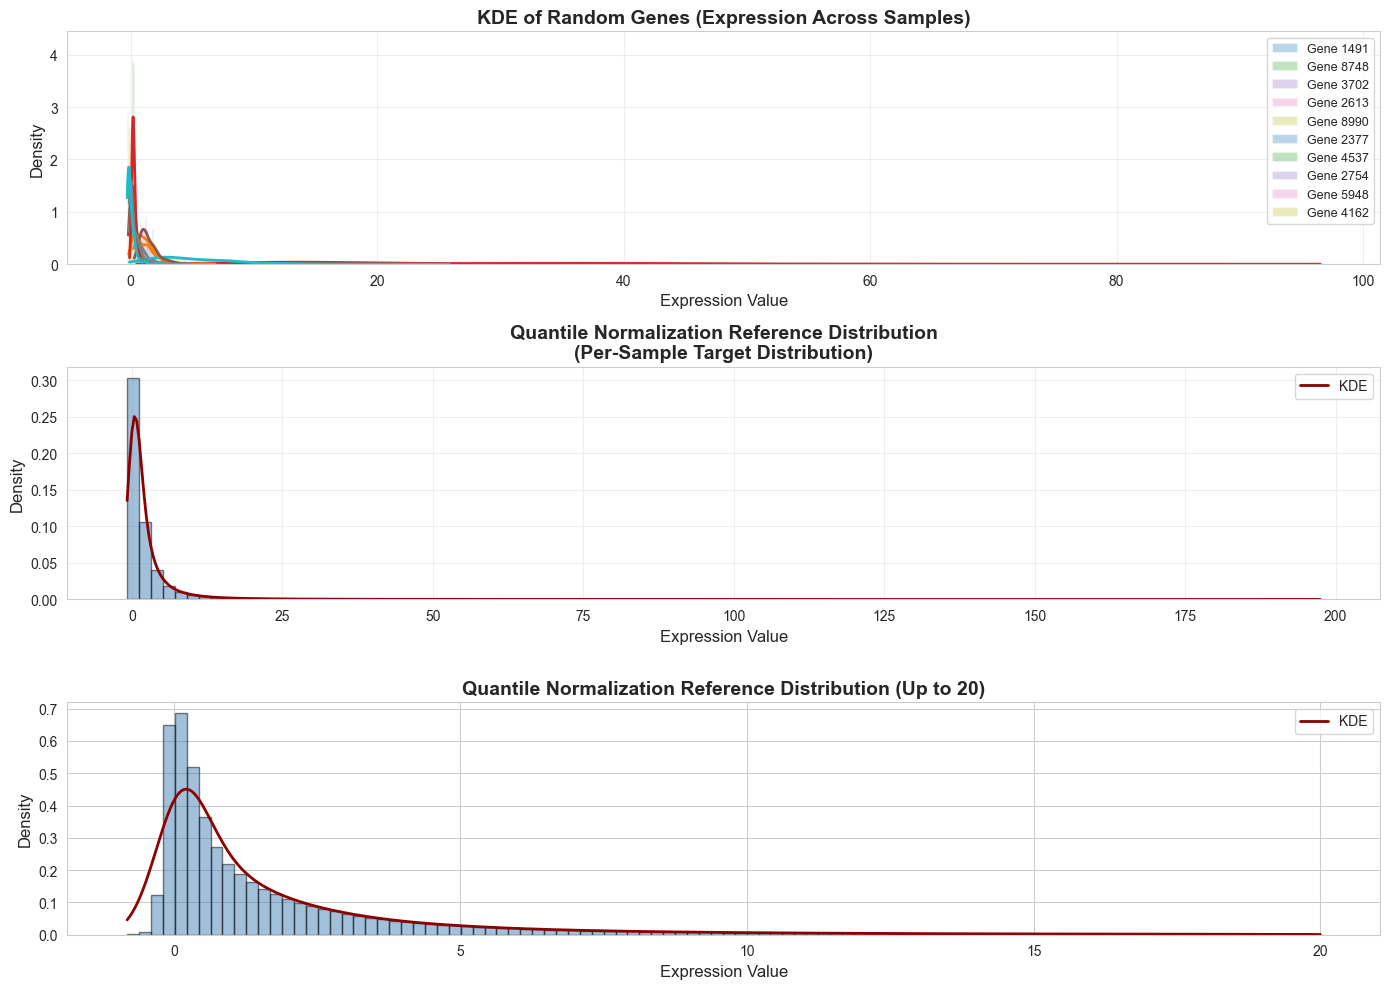

QN Reference - Min: -0.82, Max: 197.48, Mean: 2.50
Gene expression - Min: -0.82, Max: 197.48, Mean: 2.51

KDE analysis plot saved to: ../data/gene_expression_kde_analysis.png


In [39]:
# Load quantile normalization reference
qn_reference = np.load('../data/homo_sapiens_qn_reference.npy')

# Select random genes for visualization
np.random.seed(42)
n_random_genes = 10
random_gene_indices = np.random.choice(genexp_filtered.shape[1], n_random_genes, replace=False)

# Create figure with subplots
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Plot 1: KDE of random genes
ax1 = axes[0]
for idx in random_gene_indices:
    gene_values = genexp_filtered[:, idx]
    ax1.hist(gene_values, bins=50, alpha=0.3, density=True, label=f'Gene {idx}')
    # Add KDE
    from scipy import stats
    density = stats.gaussian_kde(gene_values)
    x_range = np.linspace(gene_values.min(), gene_values.max(), 200)
    ax1.plot(x_range, density(x_range), linewidth=2)

ax1.set_xlabel('Expression Value', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('KDE of Random Genes (Expression Across Samples)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Plot 2: KDE of quantile normalization reference distribution
ax2 = axes[1]
ax2.hist(qn_reference, bins=100, alpha=0.5, density=True, color='steelblue', edgecolor='black')
# Add KDE
density_qn = stats.gaussian_kde(qn_reference)
x_range_qn = np.linspace(qn_reference.min(), qn_reference.max(), 500)
ax2.plot(x_range_qn, density_qn(x_range_qn), linewidth=2, color='darkred', label='KDE')

ax2.set_xlabel('Expression Value', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Quantile Normalization Reference Distribution\n(Per-Sample Target Distribution)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# Plot 3: KDE of quantile normalization reference distribution, up to 20
ax3 = axes[2]
ax3.hist(qn_reference[qn_reference <= 20], bins=100, alpha=0.5, density=True, color='steelblue', edgecolor='black')
# Add KDE
density_qn = stats.gaussian_kde(qn_reference[qn_reference <= 20])
x_range_qn = np.linspace(qn_reference.min(), 20, 500)
ax3.plot(x_range_qn, density_qn(x_range_qn), linewidth=2, color='darkred', label='KDE')

ax3.set_xlabel('Expression Value', fontsize=12)
ax3.set_ylabel('Density', fontsize=12)
ax3.set_title('Quantile Normalization Reference Distribution (Up to 20)', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/gene_expression_kde_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"QN Reference - Min: {qn_reference.min():.2f}, Max: {qn_reference.max():.2f}, Mean: {qn_reference.mean():.2f}")
print(f"Gene expression - Min: {genexp_filtered.min():.2f}, Max: {genexp_filtered.max():.2f}, Mean: {genexp_filtered.mean():.2f}")
print("\nKDE analysis plot saved to: ../data/gene_expression_kde_analysis.png")

we can see from the gene level plots that most of the values make biological sense for values expressed in log 2 scale. 

## 9. Save Cleaned Data

## Summary

Quality control steps completed:
1. ✓ Loaded gene expression data
2. ✓ Performed exploratory data analysis
3. ✓ Checked for NaN, null, and infinite values
4. ✓ Identified all-zero samples
5. ✓ Checked for duplicate samples
6. ✓ Filtered all-zero genes
7. ✓ Analyzed expression distribution
8. ✓ Generated QC visualizations
9. ✓ Saved cleaned data

Ready for Stage 3: Build Dataset

In [42]:
# Save to CSV
genexp_cleaned_df = pd.DataFrame(genexp_filtered)
output_path = '../data/rb_trastuzumab_genexp_cleaned.csv'
genexp_cleaned_df.to_csv(output_path, index=False)

print(f"\nCleaned gene expression data saved to: {output_path}")
print(f"Final shape: {genexp_filtered.shape}")
print(f"Samples: {genexp_filtered.shape[0]}")
print(f"Genes: {genexp_filtered.shape[1]}")


Cleaned gene expression data saved to: ../data/rb_trastuzumab_genexp_cleaned.csv
Final shape: (374, 11868)
Samples: 374
Genes: 11868
